ESCENARIO 03 CHATGPT - CON REGLAS, VERSIÓN GRATIS

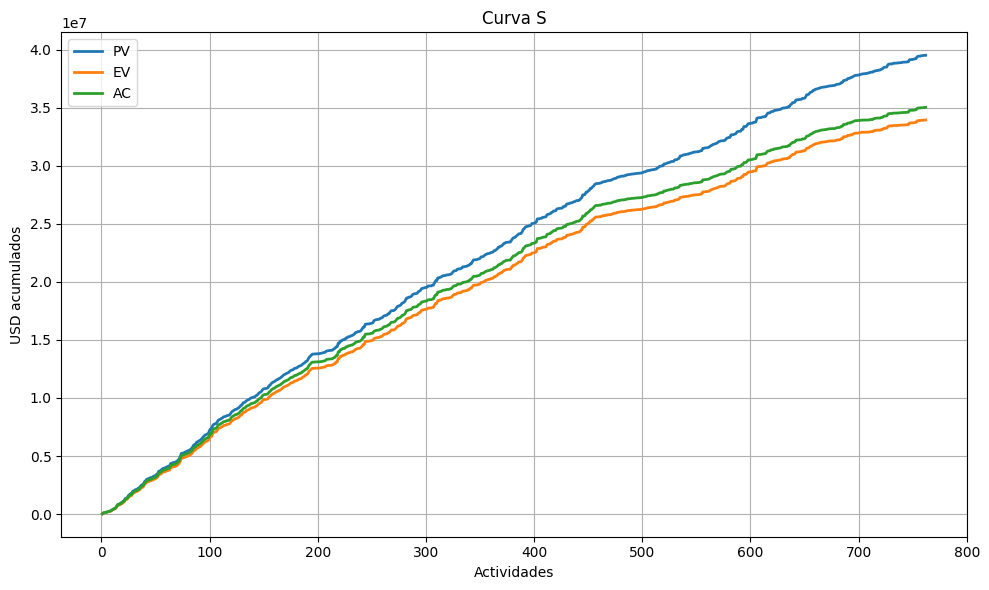

RESULTADOS

Avance físico consolidado: 61.14%

Avance por disciplina:
 - Civil: 87.39%
 - Eléctrica: 51.46%
 - Instrumentación: 31.42%
 - Mecánica estática: 69.27%
 - Rotativa: 26.21%

Indicadores EVM
PV : 39520591.76
EV : 33947130.85
AC : 35031285.00
SPI: 0.859
CPI: 0.969

Interpretación:
SPI: Atraso
CPI: Sobrecosto

Inconsistencias detectadas:
- ID STAP-CIV-005: cantidad ejecutada mayor que la planificada.
- ID STAP-MEC-012: cantidad ejecutada mayor que la planificada.
- ID STAP-ELE-007: cantidad ejecutada mayor que la planificada.
- ID STAP-ROT-015: peso presupuestal nulo, negativo o ausente.
- ID STAP-CIV-030: unidad no reconocida (m^3).
- ID STAP-INS-009: unidad no reconocida (ml).
- ID STAP-ELE-019: actividad duplicada.
- ID STAP-ELE-019: actividad duplicada.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Configuración
# ==========================================================
ARCHIVO = "02_Dataset_Base_STAP.csv"

UNIDADES_VALIDAS = {
    "pulg_diam",
    "kg",
    "m",
    "m2",
    "m3",
    "und"
}

DISCIPLINAS_VALIDAS = {
    "Civil",
    "Mecánica estática",
    "Rotativa",
    "Instrumentación",
    "Eléctrica"
}

# ==========================================================
# Lectura del archivo
# ==========================================================
try:
    df = pd.read_csv(ARCHIVO, encoding="utf-8")
except Exception as e:
    print(f"Error al leer el archivo '{ARCHIVO}': {e}")
    raise SystemExit()

# ==========================================================
# Conversión de columnas numéricas
# ==========================================================
columnas_numericas = [
    "cantidad_planificada",
    "cantidad_ejecutada",
    "peso_presupuesto_usd",
    "avance_planificado_pct",
    "costo_real_usd"
]

for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ==========================================================
# Lista de inconsistencias
# ==========================================================
inconsistencias = []

# ==========================================================
# Validaciones
# ==========================================================

# Cantidad ejecutada mayor que planificada
mask = (
    df["cantidad_ejecutada"].notna()
    & df["cantidad_planificada"].notna()
    & (df["cantidad_ejecutada"] > df["cantidad_planificada"])
)

for _, fila in df.loc[mask].iterrows():
    inconsistencias.append(
        f"ID {fila['id_actividad']}: cantidad ejecutada mayor que la planificada."
    )

# Peso presupuestal nulo, negativo o ausente
mask = (
    df["peso_presupuesto_usd"].isna()
    | (df["peso_presupuesto_usd"] <= 0)
)

for _, fila in df.loc[mask].iterrows():
    inconsistencias.append(
        f"ID {fila['id_actividad']}: peso presupuestal nulo, negativo o ausente."
    )

# Unidad no reconocida
mask = ~df["unidad"].isin(UNIDADES_VALIDAS)

for _, fila in df.loc[mask].iterrows():
    inconsistencias.append(
        f"ID {fila['id_actividad']}: unidad no reconocida ({fila['unidad']})."
    )

# ID duplicado
duplicados = df[df["id_actividad"].duplicated(keep=False)]

for _, fila in duplicados.iterrows():
    inconsistencias.append(
        f"ID {fila['id_actividad']}: actividad duplicada."
    )

# Disciplina no reconocida
mask = ~df["disciplina"].isin(DISCIPLINAS_VALIDAS)

for _, fila in df.loc[mask].iterrows():
    inconsistencias.append(
        f"ID {fila['id_actividad']}: disciplina no reconocida ({fila['disciplina']})."
    )

# Avance planificado fuera de rango
mask = (
    df["avance_planificado_pct"].isna()
    | (df["avance_planificado_pct"] < 0)
    | (df["avance_planificado_pct"] > 1)
)

for _, fila in df.loc[mask].iterrows():
    inconsistencias.append(
        f"ID {fila['id_actividad']}: avance_planificado_pct fuera del rango [0,1]."
    )

# ==========================================================
# Cálculo del avance por actividad
# ==========================================================

avance = df["cantidad_ejecutada"] / df["cantidad_planificada"]

avance = avance.clip(lower=0, upper=1)

avance = avance.fillna(0)

df["avance"] = avance

# ==========================================================
# Avance físico consolidado
# ==========================================================

pesos = df["peso_presupuesto_usd"].fillna(0)

suma_pesos = pesos.sum()

if suma_pesos > 0:
    avance_consolidado = (df["avance"] * pesos).sum() / suma_pesos
else:
    avance_consolidado = 0

# ==========================================================
# Avance por disciplina
# ==========================================================

avance_disciplina = {}

for disciplina, grupo in df.groupby("disciplina"):

    peso = grupo["peso_presupuesto_usd"].fillna(0).sum()

    if peso > 0:
        valor = (
            (grupo["avance"] * grupo["peso_presupuesto_usd"].fillna(0)).sum()
            / peso
        )
    else:
        valor = 0

    avance_disciplina[disciplina] = valor

# ==========================================================
# EVM
# ==========================================================

PV = (
    (
        df["peso_presupuesto_usd"].fillna(0)
        * df["avance_planificado_pct"].fillna(0)
    ).sum()
)

EV = (
    (
        df["peso_presupuesto_usd"].fillna(0)
        * df["avance"]
    ).sum()
)

AC = df["costo_real_usd"].fillna(0).sum()

SPI = EV / PV if PV != 0 else None
CPI = EV / AC if AC != 0 else None

# ==========================================================
# Interpretación
# ==========================================================

if SPI is None:
    interpretacion_spi = "No se puede calcular (PV = 0)"
elif SPI > 1:
    interpretacion_spi = "Adelanto"
elif SPI < 1:
    interpretacion_spi = "Atraso"
else:
    interpretacion_spi = "Según plan"

if CPI is None:
    interpretacion_cpi = "No se puede calcular (AC = 0)"
elif CPI > 1:
    interpretacion_cpi = "Ahorro"
elif CPI < 1:
    interpretacion_cpi = "Sobrecosto"
else:
    interpretacion_cpi = "Según presupuesto"

# ==========================================================
# Curva S
# ==========================================================

df_plot = df.copy()

df_plot["PV"] = (
    df_plot["peso_presupuesto_usd"].fillna(0)
    * df_plot["avance_planificado_pct"].fillna(0)
)

df_plot["EV"] = (
    df_plot["peso_presupuesto_usd"].fillna(0)
    * df_plot["avance"]
)

df_plot["AC"] = df_plot["costo_real_usd"].fillna(0)

df_plot["PV_acum"] = df_plot["PV"].cumsum()
df_plot["EV_acum"] = df_plot["EV"].cumsum()
df_plot["AC_acum"] = df_plot["AC"].cumsum()

plt.figure(figsize=(10, 6))

plt.plot(
    df_plot.index + 1,
    df_plot["PV_acum"],
    label="PV",
    linewidth=2
)

plt.plot(
    df_plot.index + 1,
    df_plot["EV_acum"],
    label="EV",
    linewidth=2
)

plt.plot(
    df_plot.index + 1,
    df_plot["AC_acum"],
    label="AC",
    linewidth=2
)

plt.title("Curva S")
plt.xlabel("Actividades")
plt.ylabel("USD acumulados")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# Salida
# ==========================================================

print("=" * 60)
print("RESULTADOS")
print("=" * 60)

print(f"\nAvance físico consolidado: {avance_consolidado*100:.2f}%")

print("\nAvance por disciplina:")

for disciplina, valor in avance_disciplina.items():
    print(f" - {disciplina}: {valor*100:.2f}%")

print("\nIndicadores EVM")
print(f"PV : {PV:.2f}")
print(f"EV : {EV:.2f}")
print(f"AC : {AC:.2f}")

if SPI is None:
    print("SPI: No calculable")
else:
    print(f"SPI: {SPI:.3f}")

if CPI is None:
    print("CPI: No calculable")
else:
    print(f"CPI: {CPI:.3f}")

print("\nInterpretación:")

print(f"SPI: {interpretacion_spi}")
print(f"CPI: {interpretacion_cpi}")

print("\nInconsistencias detectadas:")

if len(inconsistencias) == 0:
    print("No se detectaron inconsistencias.")
else:
    for item in inconsistencias:
        print("-", item)